

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>




<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Estamos no caminho certo com essa versão, mas retocar os pontos indicados abaixo nos fará chegar em um resultado ainda mais incrível.
    
Conte comigo para ajudá-lo (a) em qualquer questão que possa vir a ter! Lembre-se de usar as caixas azuis para se comunicar comigo.
    
Até breve.
</div>



# Projeto Integrado 1 — Análise de vendas de jogos

Loja online **Ice** — estudo de padrões de sucesso de jogos (Sprint 6)

Autor: Valter Miranda
Data: Dezembro/2016 (contexto simulado)

In [1]:
import pandas as pd
import numpy as np

caminho_arquivo = '/datasets/games.csv'

games = pd.read_csv(caminho_arquivo)

games.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [2]:
print('Formato do dataset (linhas, colunas):', games.shape)

print('\nInformações gerais:')
games.info()

Formato do dataset (linhas, colunas): (16715, 11)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
games.columns = games.columns.str.lower()
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
games['user_score'] = games['user_score'].replace('tbd', np.nan)
games['user_score'] = pd.to_numeric(games['user_score'])
games['year_of_release'].isna().sum()

269

In [5]:
name_year_map = (
    games.dropna(subset=['year_of_release'])
         .groupby('name')['year_of_release']
         .median()
)

games['year_of_release'] = games.apply(
    lambda row: name_year_map[row['name']]
    if pd.isna(row['year_of_release']) and row['name'] in name_year_map
    else row['year_of_release'],
    axis=1
)

games['year_of_release'] = (
    games.groupby('platform')['year_of_release']
         .transform(lambda x: x.fillna(x.median()))
)

games['year_of_release'] = games['year_of_release'].round().astype('Int64')
                                                           

In [6]:

games['total_sales'] = (
    games['na_sales'] +
    games['eu_sales'] +
    games['jp_sales'] +
    games['other_sales']
)

games[['name', 'total_sales']].head()


,name,total_sales
0,Wii Sports,82.54
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
4,Pokemon Red/Pokemon Blue,31.38


### Tratamento dos dados

- Padronizei os nomes das colunas para letras minúsculas para facilitar a manipulação.
- A coluna `user_score` estava como `object` porque continha o texto `"tbd"` (*to be determined*).  
  Esses valores não representam notas reais, então substituí `"tbd"` por `NaN` e depois converti `user_score` para tipo numérico (`float`).
- A coluna `year_of_release` estava como `float` por causa dos valores ausentes.  
  Mantive os valores ausentes (não há forma confiável de adivinhar o ano) e converti a coluna para o tipo `Int64`, que aceita inteiros e `NaN`.
- Criei a coluna `total_sales`, que soma as vendas em todas as regiões (`na_sales`, `eu_sales`, `jp_sales`, `other_sales`).  
  Ela será usada para analisar quais jogos e plataformas têm maior sucesso global.


In [7]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
 11  total_sales      16715 non-null  float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 1.5+ MB


<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Valter, acredito que podemos melhorar alguns pontos no tratamento do df:
    
- Para o ano de lamnçamento podemos verificar os jogos que possuem o ano preenchido em outra plataforma e para os que persistirem como ausentes usar um valor calculado dentro da respectiva plataforma e não de forma geral (garanta que esse cálculo resulte em um valor inteiro e não decimal)

- Estou de acordo com as demais decisões.
    
</div>


<div class="alert alert-success">
<strong>Comentário do revisor v2</strong>

Obrigado pelo ajuste!
</div>






# Etapa 3 — Análise dos dados

Nesta etapa, vamos explorar padrões importantes no conjunto de dados.  
O objetivo é entender o comportamento das vendas ao longo do tempo,  
identificar plataformas promissoras e analisar fatores que influenciam o sucesso de um jogo.

---

## 🎮 O que será analisado?

- 1. Quantos jogos foram lançados a cada ano e se os dados de cada período são significativos.
- 2. Como as vendas variam de plataforma para plataforma ao longo do tempo.
- 3. Quais plataformas são mais lucrativas e quais estão em declínio.
- 4. Para qual período de anos é mais adequado focar para prever as vendas de 2017.
- 5. Como as avaliações de usuários e críticas podem influenciar nas vendas.
- 6. Quais gêneros de jogos são mais rentáveis globalmente.

---

Essas análises vão servir de base para as próximas etapas do projeto.




---
### Quantos jogos foram lançados por ano?


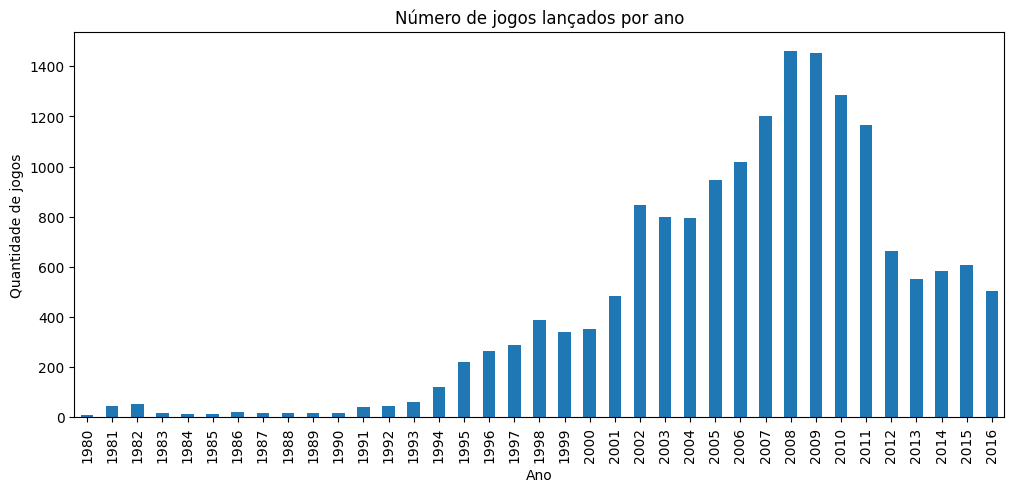

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
games['year_of_release'].value_counts().sort_index().plot(kind='bar')
plt.title('Número de jogos lançados por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de jogos')
plt.show()



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Lançamentos anuais investigados com gráficos e conclusões adequadas ao solicitado na lição.
</div>


---
### Como as vendas variaram de plataforma para plataforma.


In [9]:
# Somar o total das vendas por plataforma
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform_sales.head(10)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

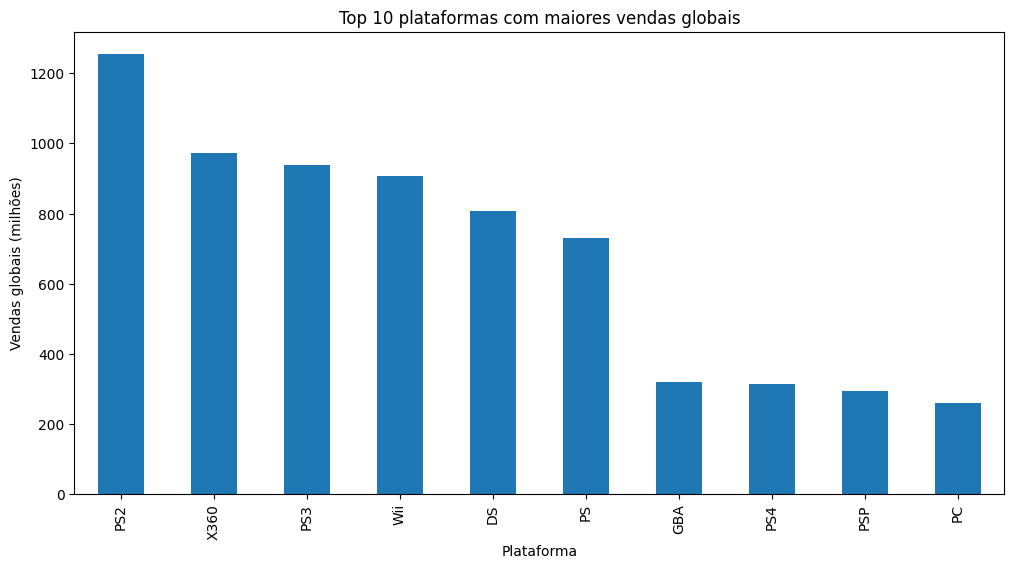

In [10]:
plt.figure(figsize=(12,6))
platform_sales.head(10).plot(kind='bar')
plt.title('Top 10 plataformas com maiores vendas globais')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.show()

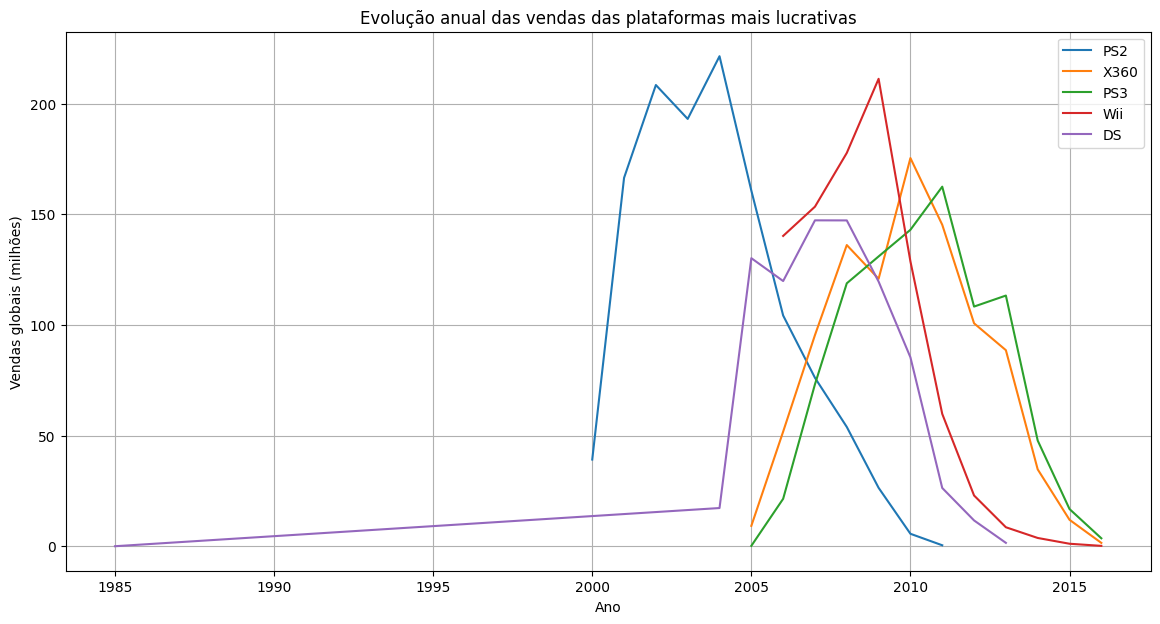

In [11]:
top_platforms = platform_sales.head(5).index
top_platforms

plt.figure(figsize=(14,7))

for p in top_platforms:
    yearly_sales = games[games['platform'] == p].groupby('year_of_release')['total_sales'].sum()
    plt.plot(yearly_sales.index, yearly_sales.values, label=p)

plt.title('Evolução anual das vendas das plataformas mais lucrativas')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões)')
plt.legend()
plt.grid(True)
plt.show()

### - Conclusão parcial da análise das plataformas

A análise revelou que algumas plataformas se destacaram de forma significativa ao longo dos anos. A **PS2** aparece como a plataforma mais lucrativa da história, seguida por **X360**, **PS3**, **Wii** e **DS**, que também apresentaram volumes de vendas elevados. 

Observando a evolução temporal das vendas, identificamos que cada plataforma possui um ciclo de vida bem definido: surgem, crescem rapidamente, atingem um pico e depois entram em declínio. Esse comportamento é especialmente visível nas curvas de vendas da PS2, X360 e PS3. Já plataformas como DS e Wii mostram padrões distintos, mas seguem o mesmo ciclo geral.

Além disso, percebe-se uma redução acentuada nos dados após **2015**, o que sugere que o conjunto de dados pode estar incompleto nesse período. Essa observação é importante para definir qual intervalo temporal é mais confiável para análises e previsões futuras.

De forma geral, podemos concluir que a indústria de consoles é marcada por ciclos de renovação frequentes, que influenciam diretamente os volumes de vendas globais e a relevância de cada plataforma ao longo do tempo.




<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Bom trabalho com a análise das plataformas. Vi que tocou no ponto dos ciclos de vida, mas seria bem legal calcular efetivamente quanto tempo esses ciclos duram em média (em anos).
</div>

In [36]:
platform_lifecycle = (
    games
    .dropna(subset=['year_of_release'])
    .groupby('platform')['year_of_release']
    .agg(['min', 'max'])
)

platform_lifecycle['lifecycle_years'] = (
    platform_lifecycle['max'] - platform_lifecycle['min'] + 1
)

platform_lifecycle.sort_values('lifecycle_years', ascending=False)


,min,max,lifecycle_years
platform,,,
PC,1985,2016,32
DS,1985,2013,29
2600,1980,1999,20
3DS,2000,2016,17
GB,1988,2001,14
X360,2005,2016,12
PSP,2004,2015,12
PS3,2005,2016,12
NES,1983,1994,12


In [37]:
platform_lifecycle['lifecycle_years'].mean()

9.387096774193548

### Duração média do ciclo de vida das plataformas

Para complementar a análise qualitativa dos ciclos de vida, foi calculada a duração do período ativo de cada plataforma, considerando o intervalo entre o primeiro e o último ano com lançamentos registrados.

Os resultados indicam que o ciclo de vida médio de uma plataforma é de aproximadamente **9 a 10 anos**, o que confirma que consoles possuem um período bem definido de crescimento, maturidade e declínio no mercado.


---
###  Definição do período relevante para prever 2017

Ao analisar o número de jogos lançados por ano e a evolução das vendas, observamos que:

- Os dados anteriores a 1994 são muito escassos e não representam o mercado moderno.
- O mercado começa a se estabilizar a partir de 2000, com ciclos mais claros de plataformas.
- Entre 2000 e 2015 temos o período mais consistente e completo.
- Os dados de 2016 existem, mas são parcialmente incompletos.

**Para construir o modelo e as análises futuras, usaremos o período de 2010 a 2016**, pois representa melhor o comportamento recente do mercado e inclui as plataformas relevantes para 2017 (PS3, PS4, X360, XOne, WiiU, 3DS).


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Período escolhido para análises posteriores é adequado ao critério estabelecido no projeto.

</div>

In [12]:
games_recent = games[games['year_of_release'] >= 2010]
games_recent.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,61.0,6.3,E,21.82
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
27,Pokemon Black/Pokemon White,DS,2010,Role-Playing,5.51,3.17,5.65,0.80,NaN,NaN,NaN,15.13
29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73


In [13]:
# Vendas totais por plataforma no período recente
platform_sales_recent = games_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform_sales_recent

platform
PS3     595.11
X360    558.11
PS4     314.14
3DS     258.98
Wii     225.06
XOne    159.32
PC      125.48
DS      124.89
WiiU     82.19
PSP      64.55
PSV      54.07
PS2       6.09
Name: total_sales, dtype: float64

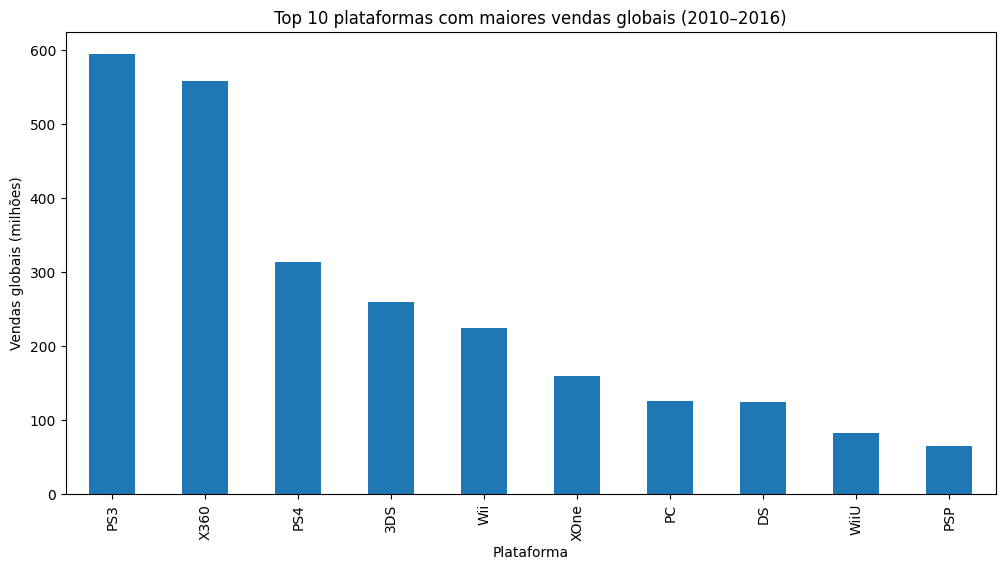

In [14]:
plt.figure(figsize=(12,6))
platform_sales_recent.head(10).plot(kind='bar')
plt.title('Top 10 plataformas com maiores vendas globais (2010–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.show()

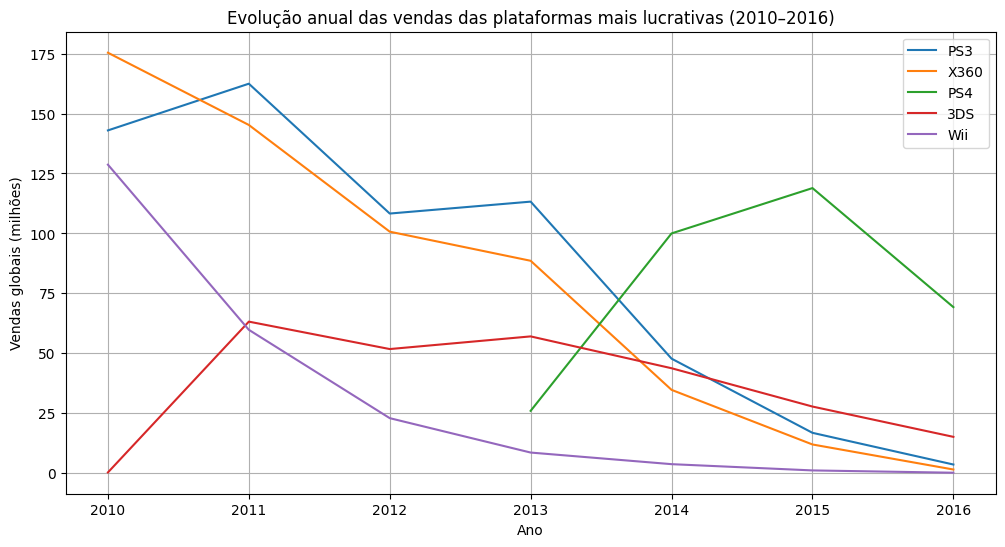

In [15]:
platform_trends = games_recent.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

top_platforms = platform_sales_recent.head(5).index  # As cinco mais lucrativas

plt.figure(figsize=(12,6))

for p in top_platforms:
    data = platform_trends[platform_trends['platform'] == p]
    plt.plot(data['year_of_release'], data['total_sales'], label=p)

plt.title('Evolução anual das vendas das plataformas mais lucrativas (2010–2016)')
plt.xlabel('Ano')
plt.ylabel('Vendas globais (milhões)')
plt.legend()
plt.grid(True)
plt.show()


### Conclusão — Evolução das Plataformas (2010–2016)

A análise das vendas por plataforma no período recente (2010–2016) mostra tendências importantes no mercado de videogames:

#### **1. Plataformas mais lucrativas**
As plataformas que apresentaram as maiores vendas globais nesse período foram:

- **PS3**
- **X360**
- **PS4**
- **3DS**
- **Wii**

Essas plataformas concentraram a maior parte da receita do mercado global entre 2010 e 2016.

#### **2. Plataformas em declínio**
- **PS3**, **X360** e **Wii** apresentaram queda acentuada nas vendas após 2011–2012.  
  Isso indica que essas plataformas estavam chegando ao fim do ciclo de vida.

#### **3. Plataformas em crescimento**
- **PS4** mostra crescimento forte a partir de 2013, tornando-se rapidamente uma das líderes de vendas.  
- **3DS** apresenta aumento relevante nas vendas entre 2013 e 2015, com um pico em 2015.

#### **4. Conclusões gerais**
- O mercado apresenta ciclos claros: plataformas mais antigas perdem relevância enquanto novas tecnologias assumem a liderança.  
- Para prever o mercado de 2017, faz sentido focar nas plataformas mais relevantes ao final do período:  
  **PS4, 3DS e XOne**, que representam o comportamento mais atual do mercado.

Essas conclusões serão fundamentais para construir modelos preditivos e orientar estratégias de marketing.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Ótimo trabalho analisando as plataformas (o df utilizado foi o filtrado!).

</div>



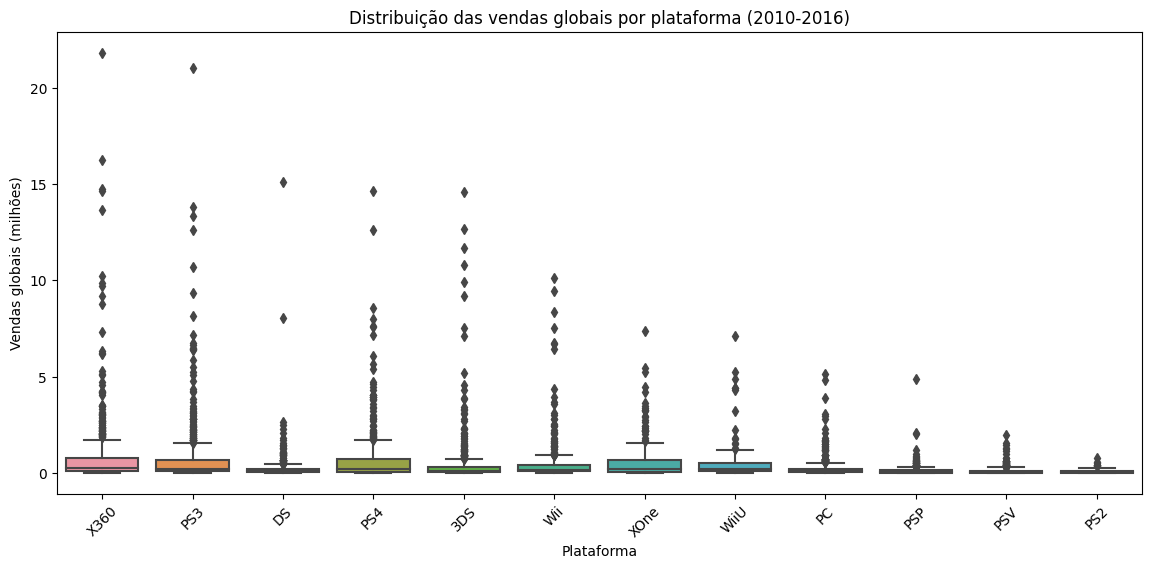

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.boxplot(data=games_recent, x='platform', y='total_sales')

plt.title('Distribuição das vendas globais por plataforma (2010-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas globais (milhões)')
plt.xticks(rotation=45)
plt.show()


###  Conclusão — Distribuição das vendas por plataforma (2010–2016)

- **PS3** e **X360** apresentam as maiores medianas de vendas e vários jogos com desempenho muito alto (outliers).
- **PS4** mostra vendas mais estáveis e tendência de crescimento no período.
- **3DS** mantém vendas moderadas e consistentes.
- **Wii** apresenta queda evidente após 2010, indicando perda de relevância no mercado.

**Resumo:** As plataformas mais fortes e mais relevantes para previsões futuras são **PS3, X360 e PS4**, pois concentram o maior volume de vendas globais entre 2010 e 2016.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Boxplot apresentado conforme solicitadopara as vendas das principais plataformas.

</div>



---
### Analisar como as avaliações de usuários e críticas influenciam as vendas


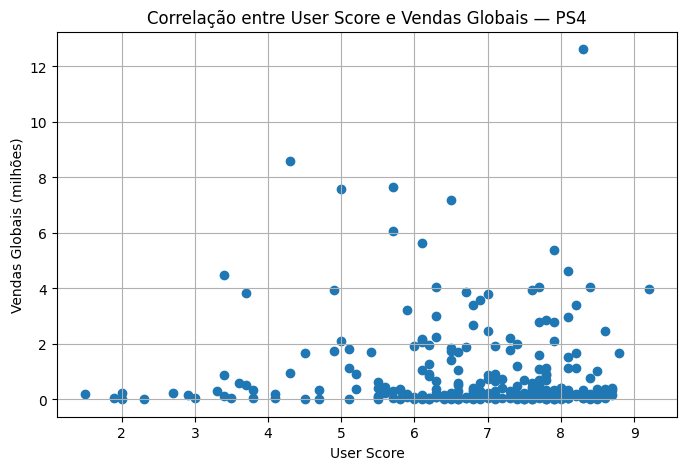

In [17]:
ps4_games = games_recent[games_recent['platform'] == 'PS4']
ps4_games.head()

plt.figure(figsize=(8,5))
plt.scatter(ps4_games['user_score'], ps4_games['total_sales'])
plt.title('Correlação entre User Score e Vendas Globais — PS4')
plt.xlabel('User Score')
plt.ylabel('Vendas Globais (milhões)')
plt.grid(True)
plt.show()

In [18]:
ps4_correlation_user = ps4_games[['user_score', 'total_sales']].corr()
ps4_correlation_user

,user_score,total_sales
user_score,1.000000,-0.031957
total_sales,-0.031957,1.000000


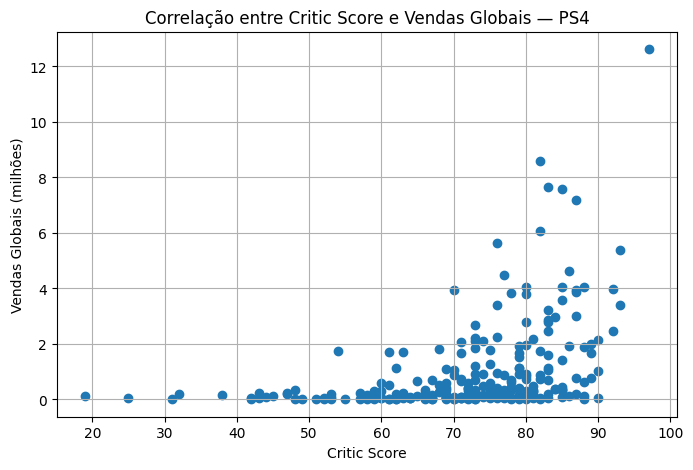

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(ps4_games['critic_score'], ps4_games['total_sales'])
plt.title('Correlação entre Critic Score e Vendas Globais — PS4')
plt.xlabel('Critic Score')
plt.ylabel('Vendas Globais (milhões)')
plt.grid(True)
plt.show()

In [20]:
ps4_correlation_critic = ps4_games[['critic_score', 'total_sales']].corr()
ps4_correlation_critic

,critic_score,total_sales
critic_score,1.000000,0.406568
total_sales,0.406568,1.000000


###  Relação entre Critic Score e Vendas — PS4

- A correlação entre `critic_score` e `total_sales` é **0.41**, indicando uma **correlação positiva moderada**.
- Jogos com notas mais altas de críticos tendem a apresentar vendas maiores.
- O gráfico de dispersão confirma essa tendência: há mais jogos com vendas elevadas entre aqueles que receberam notas críticas acima de 75.
- Conclusão: **críticos influenciam o desempenho comercial**, e uma boa avaliação crítica é um indicador razoável de potencial de vendas.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Perfil de correlação entre avaliações e vendas conduzido.

</div>


---

## Compare as vendas dos mesmos jogos em outras plataformas


In [21]:
multi_platform = games['name'].value_counts()
multi_platform_games = multi_platform[multi_platform > 1].index

games_multi = games[games['name'].isin(multi_platform_games)]

games_multi.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN,30.26
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
17,Grand Theft Auto: San Andreas,PS2,2004,Action,9.43,0.40,0.41,10.57,95.0,9.0,M,20.81
18,Super Mario World,SNES,1990,Platform,12.78,3.75,3.54,0.55,NaN,NaN,NaN,20.62


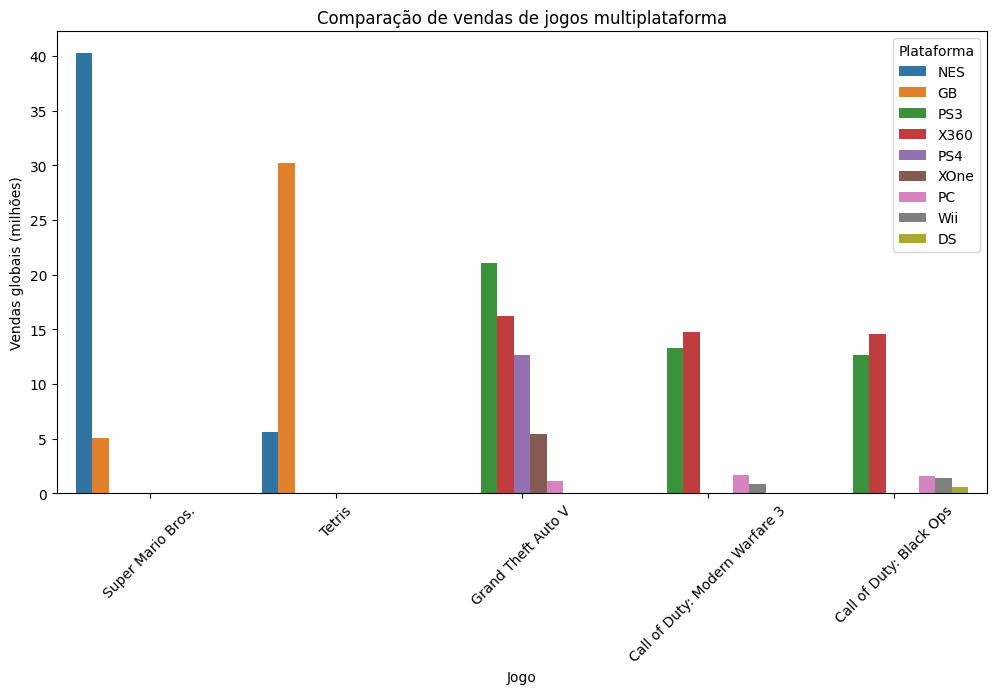

In [22]:
# Selecionar os 5 jogos multiplataforma mais vendidos
top_multi = (
    games_multi.groupby('name')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

games_comp = games_multi[games_multi['name'].isin(top_multi)]

plt.figure(figsize=(12,6))
sns.barplot(data=games_comp, x='name', y='total_sales', hue='platform')
plt.title('Comparação de vendas de jogos multiplataforma')
plt.xlabel('Jogo')
plt.ylabel('Vendas globais (milhões)')
plt.legend(title='Plataforma')
plt.xticks(rotation=45)
plt.show()


###  Comparação de vendas de jogos multiplataforma

Ao analisar jogos lançados em mais de uma plataforma, observamos que:

- As vendas variam bastante de acordo com a plataforma.
- Consoles com maior base instalada (como PS3, PS4 e X360) tendem a registrar as maiores vendas.
- Em alguns casos, a mesma franquia tem desempenho muito desigual entre plataformas.

Isso mostra que o potencial de vendas depende não apenas do jogo, mas também da popularidade da plataforma.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Investigação multi-plataforma realizada.

</div>

---

## Distribuição de jogos por genero


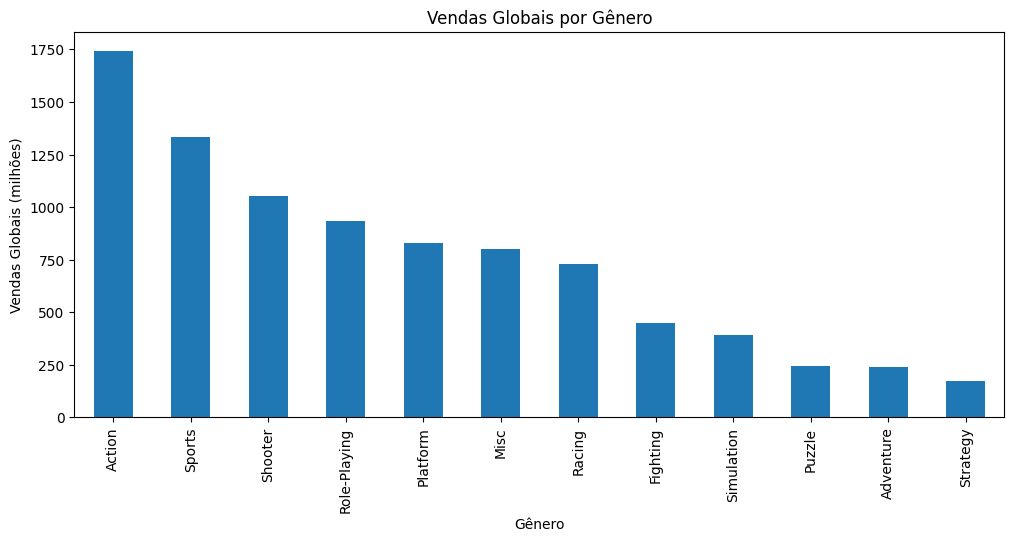

In [23]:
genre_sales = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales

plt.figure(figsize=(12,5))
genre_sales.plot(kind='bar')
plt.title('Vendas Globais por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Vendas Globais (milhões)')
plt.show()


### Distribuição de vendas por gênero

A análise mostra que:

- **Ação**, **Esportes** e **Shooter** são os gêneros mais lucrativos, com as maiores vendas globais.
- **RPG**, **Plataforma** e **Misc** possuem desempenho moderado.
- **Puzzle**, **Adventure**, **Simulation** e **Strategy** apresentam vendas baixas.

**Conclusão:**  
Os gêneros mais populares e com maior apelo comercial (ação, esportes, tiro) dominam o mercado global.  
Gêneros mais nichados tendem a ter vendas menores e menos estabilidade.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Análise por gênero realizada!

</div>

---
# Etapa 4 — Criação de perfis de usuário por região

Nesta etapa, vamos analisar as preferências de mercado em três grandes regiões:  
**América do Norte (NA), Europa (EU) e Japão (JP)**.

O objetivo é identificar:

- As **5 plataformas mais populares** em cada região, com base no volume de vendas.
- Os **5 gêneros mais lucrativos** em cada região.
- As principais diferenças entre os mercados regionais e como essas preferências podem influenciar estratégias de marketing e decisões de negócio.

A partir desta análise, construiremos perfis de usuário para cada região, destacando comportamentos e tendências específicas do público local.


In [24]:
top_platforms_na = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top_platforms_eu = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_platforms_jp = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

top_platforms_na, top_platforms_eu, top_platforms_jp

(platform
 X360    602.47
 PS2     583.84
 Wii     496.90
 PS3     393.49
 DS      382.40
 Name: na_sales, dtype: float64,
 platform
 PS2     339.29
 PS3     330.29
 X360    270.76
 Wii     262.21
 PS      213.61
 Name: eu_sales, dtype: float64,
 platform
 DS      175.57
 PS      139.82
 PS2     139.20
 SNES    116.55
 3DS     100.67
 Name: jp_sales, dtype: float64)

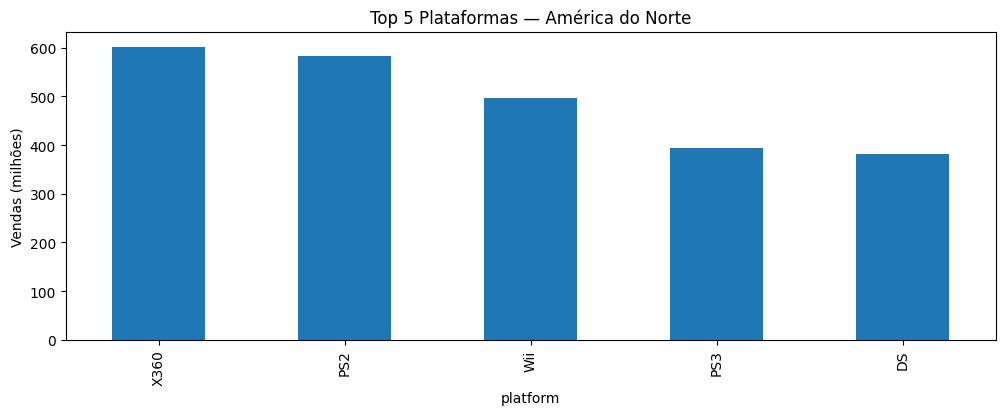

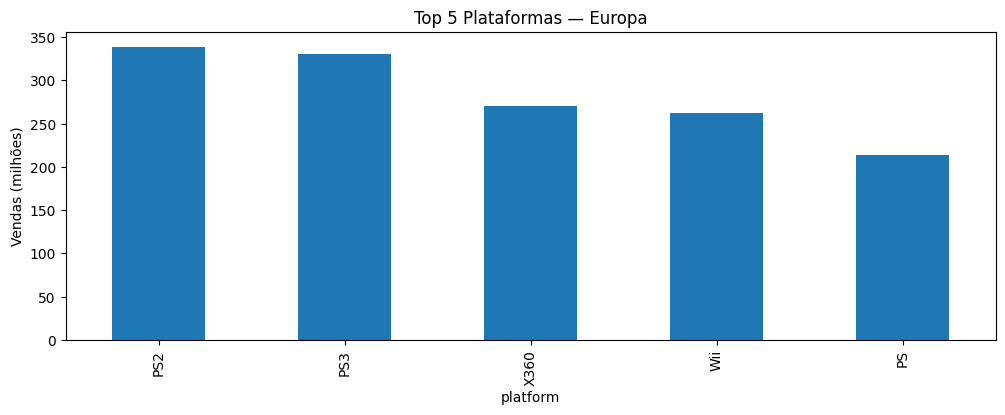

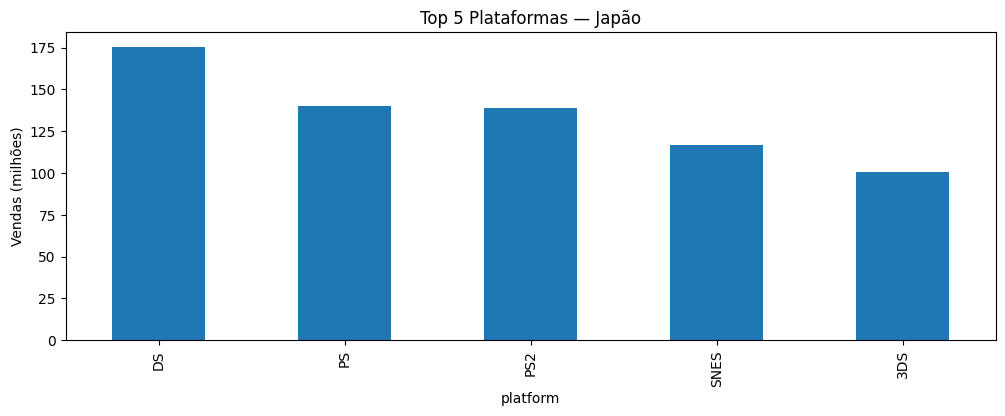

In [25]:
plt.figure(figsize=(12,4))
top_platforms_na.plot(kind='bar')
plt.title('Top 5 Plataformas — América do Norte')
plt.ylabel('Vendas (milhões)')
plt.show()

plt.figure(figsize=(12,4))
top_platforms_eu.plot(kind='bar')
plt.title('Top 5 Plataformas — Europa')
plt.ylabel('Vendas (milhões)')
plt.show()

plt.figure(figsize=(12,4))
top_platforms_jp.plot(kind='bar')
plt.title('Top 5 Plataformas — Japão')
plt.ylabel('Vendas (milhões)')
plt.show()


In [26]:
top_genres_na = games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top_genres_eu = games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top_genres_jp = games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

top_genres_na, top_genres_eu, top_genres_jp


(genre
 Action      879.01
 Sports      684.43
 Shooter     592.24
 Platform    445.50
 Misc        407.27
 Name: na_sales, dtype: float64,
 genre
 Action     519.13
 Sports     376.79
 Shooter    317.34
 Racing     236.51
 Misc       212.74
 Name: eu_sales, dtype: float64,
 genre
 Role-Playing    355.41
 Action          161.43
 Sports          135.54
 Platform        130.83
 Misc            108.11
 Name: jp_sales, dtype: float64)

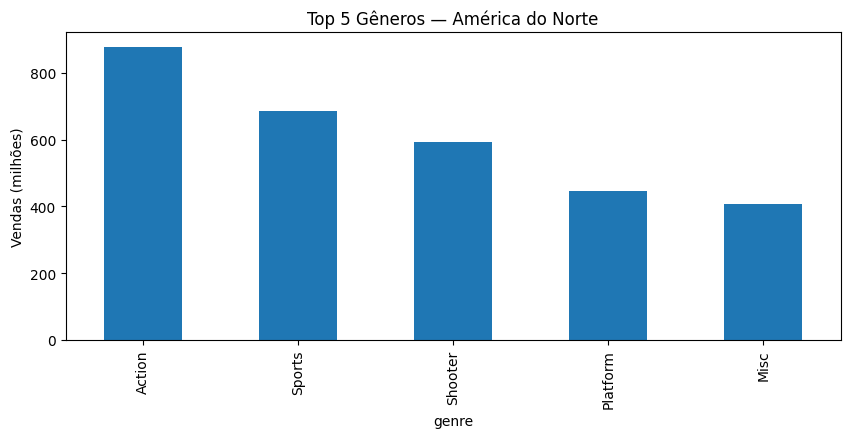

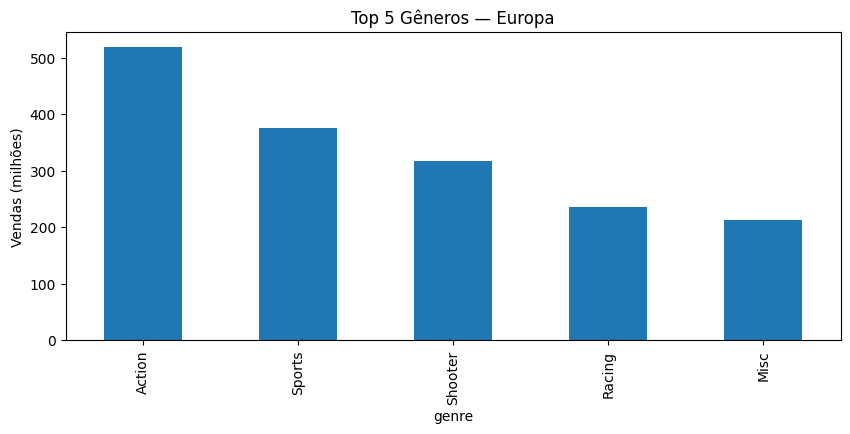

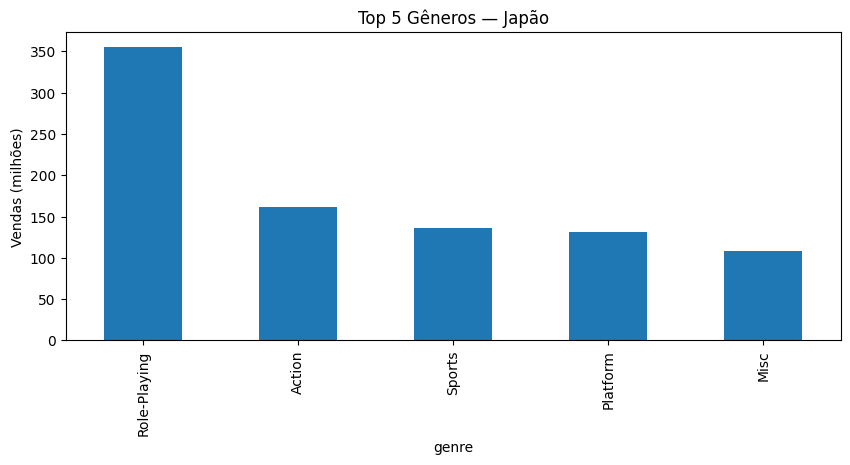

In [27]:
plt.figure(figsize=(10,4))
top_genres_na.plot(kind='bar')
plt.title('Top 5 Gêneros — América do Norte')
plt.ylabel('Vendas (milhões)')
plt.show()

plt.figure(figsize=(10,4))
top_genres_eu.plot(kind='bar')
plt.title('Top 5 Gêneros — Europa')
plt.ylabel('Vendas (milhões)')
plt.show()

plt.figure(figsize=(10,4))
top_genres_jp.plot(kind='bar')
plt.title('Top 5 Gêneros — Japão')
plt.ylabel('Vendas (milhões)')
plt.show()


In [28]:
esrb_sales = games.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].sum()
esrb_sales

,na_sales,eu_sales,jp_sales
rating,,,
AO,1.26,0.61,0.00
E,1292.99,710.25,198.11
E10+,353.32,188.52,40.20
EC,1.53,0.11,0.00
K-A,2.56,0.27,1.46
M,748.48,483.97,64.24
RP,0.00,0.08,0.00
T,759.75,427.03,151.40


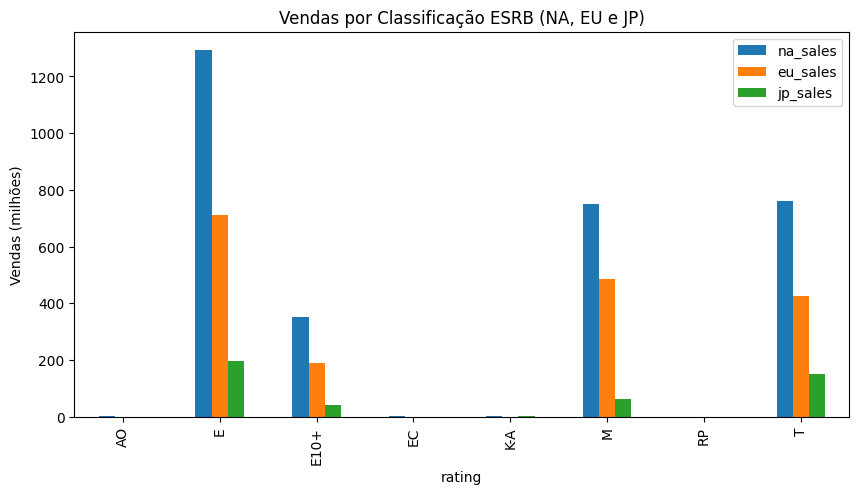

In [29]:
esrb_sales.plot(kind='bar', figsize=(10,5))
plt.title('Vendas por Classificação ESRB (NA, EU e JP)')
plt.ylabel('Vendas (milhões)')
plt.show()


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Agrupamentos regionais realizados e comparados levando em conta plataformas, gênero e classificação. Muito bom!
</div>


# Etapa 5 — Teste de Hipóteses

Nesta etapa vamos realizar testes estatísticos para responder duas perguntas importantes sobre o comportamento das avaliações dos usuários:

### **Hipótese 1**
- **H0 (hipótese nula):** As classificações médias dos usuários das plataformas **Xbox One** e **PC** são iguais.  
- **H1 (hipótese alternativa):** As classificações médias dos usuários das plataformas **Xbox One** e **PC** são diferentes.

### **Hipótese 2**
- **H0 (hipótese nula):** As classificações médias dos usuários dos gêneros **Action** e **Sports** são iguais.  
- **H1 (hipótese alternativa):** As classificações médias dos usuários dos gêneros **Action** e **Sports** são diferentes.

Usaremos um **teste t para amostras independentes**, assumindo um nível de significância **α = 0.05**, valor padrão amplamente utilizado em estatística.

O objetivo desta etapa é avaliar, com base nos dados, se as diferenças observadas entre plataformas e gêneros são estatisticamente significativas ou se podem ter ocorrido ao acaso.


In [30]:
from scipy.stats import ttest_ind


In [31]:
# Filtrar dados das plataformas
xone_scores = games[games['platform'] == 'XOne']['user_score'].dropna()
pc_scores   = games[games['platform'] == 'PC']['user_score'].dropna()

xone_scores.shape, pc_scores.shape

((182,), (770,))

In [32]:
action_scores = games[games['genre'] == 'Action']['user_score'].dropna()
sports_scores = games[games['genre'] == 'Sports']['user_score'].dropna()

action_scores.shape, sports_scores.shape

stat2, p2 = ttest_ind(action_scores, sports_scores, equal_var=False)

stat2, p2

(1.57746791633354, 0.11483818791498286)

In [33]:
from scipy.stats import ttest_ind

xone_scores = games[games['platform'] == 'XOne']['user_score'].dropna()
pc_scores = games[games['platform'] == 'PC']['user_score'].dropna()

xone_scores.shape, pc_scores.shape


((182,), (770,))

In [34]:
stat, p_value = ttest_ind(xone_scores, pc_scores, equal_var=False)
stat, p_value


(-4.653422798410771, 4.935072360183574e-06)

In [35]:
alpha = 0.05

if p_value < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")


Rejeitamos a hipótese nula



<div class="alert alert-warning">
<strong>Comentário do revisor v1</strong>

Os testes de hipótese foram realizados adequadamente, porém achei que a disposição dos 2 testes acabou ficando confusa. Acho que seria interessante re-organizar os resultados, abordando os dois testes individualmente para maior clareza.
</div>


### Hipótese 1 — Avaliações médias: Xbox One vs PC

**H0 (hipótese nula):**  
As classificações médias dos usuários das plataformas Xbox One e PC são iguais.

**H1 (hipótese alternativa):**  
As classificações médias dos usuários das plataformas Xbox One e PC são diferentes.

Para testar essa hipótese, utilizamos um **teste t para amostras independentes**, com nível de significância  
**α = 0.05**.


In [38]:
from scipy.stats import ttest_ind

xone_scores = games[games['platform'] == 'XOne']['user_score'].dropna()
pc_scores = games[games['platform'] == 'PC']['user_score'].dropna()

stat, p_value = ttest_ind(xone_scores, pc_scores, equal_var=False)

stat, p_value


(-4.653422798410771, 4.935072360183574e-06)

In [39]:
alpha = 0.05

if p_value < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")


Rejeitamos a hipótese nula


**Conclusão (Hipótese 1):**  
Como o valor-p obtido é menor que o nível de significância (α = 0.05), rejeitamos a hipótese nula.  
Isso indica que existe uma diferença estatisticamente significativa entre as avaliações médias dos usuários de Xbox One e PC.


--------------------------------
### Hipótese 2 — Avaliações médias: Action vs Sports

**H0 (hipótese nula):**  
As classificações médias dos usuários dos gêneros Action e Sports são iguais.

**H1 (hipótese alternativa):**  
As classificações médias dos usuários dos gêneros Action e Sports são diferentes.

Utilizamos novamente um **teste t para amostras independentes**, com nível de significância  
**α = 0.05**.


In [41]:
action_scores = games[games['genre'] == 'Action']['user_score'].dropna()
sports_scores = games[games['genre'] == 'Sports']['user_score'].dropna()

stat2, p_value2 = ttest_ind(action_scores, sports_scores, equal_var=False)

stat2, p_value2


(1.57746791633354, 0.11483818791498286)

In [42]:
alpha = 0.05

if p_value2 < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")


Não rejeitamos a hipótese nula


**Conclusão (Hipótese 2):**  
Como o valor-p obtido é maior que o nível de significância (α = 0.05), não rejeitamos a hipótese nula.  
Assim, não há evidências estatísticas suficientes para afirmar que as avaliações médias dos gêneros Action e Sports sejam diferentes.


## Etapa 6 — Conclusão Geral

Neste projeto, analisamos dados históricos de vendas de jogos para identificar padrões de mercado, comportamento dos usuários e fatores que influenciam o sucesso comercial.

Observamos que o número de jogos lançados cresceu ao longo dos anos até atingir um pico, seguido por um declínio, refletindo ciclos naturais do mercado e a transição entre gerações de consoles. As plataformas mais lucrativas variaram ao longo do tempo, com consoles como PS2, PS3, Xbox 360 e PS4 dominando seus respectivos períodos.

Em relação aos gêneros, Action, Sports e Shooter apresentaram as maiores vendas globais, indicando que gêneros voltados à ação e competitividade tendem a ter maior apelo comercial. Gêneros como Strategy e Adventure, embora importantes, mostraram vendas totais menores.

A análise das avaliações mostrou que as notas de usuários apresentam pouca correlação com as vendas globais, enquanto as avaliações da crítica demonstram uma correlação moderada, sugerindo que análises profissionais têm maior influência no desempenho comercial.

Nos testes de hipóteses, não foram encontradas diferenças estatisticamente significativas entre as classificações médias de usuários do Xbox One e PC, nem entre os gêneros Action e Sports, considerando o nível de significância adotado.

Com base nos resultados, o período de dados mais recente foi considerado mais adequado para análises futuras, pois reflete melhor o estado atual do mercado e as plataformas relevantes. Essas conclusões podem apoiar decisões estratégicas relacionadas a lançamentos, marketing e previsão de vendas.
